In [77]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [78]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [79]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


In [80]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [81]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.

        return state==self.goal


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        legal_actions=[]
        row, col =state
        for action in MOVES:
            dr, dc = MOVES[action]
            Row = row + dr
            Col = col + dc
            neighbour = (Row,Col)
            if self.in_bounds(neighbour):
              if self.is_free(neighbour):
                legal_actions.append(action)
        return legal_actions
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        row, col = state
        dr, dc =MOVES[action]
        Row= row+dr
        Col=col+dc
        return (Row , Col)
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        return 1
        # In this lab, each valid move has a cost of 1.
        # Return 1.


In [82]:

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [83]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [84]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

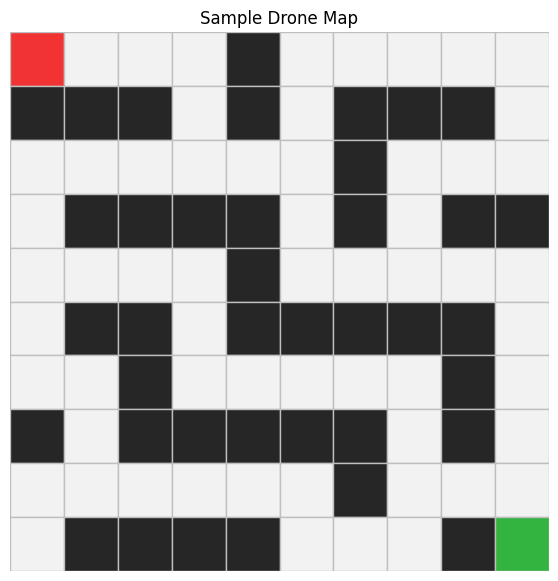

In [85]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [86]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
         s =node.state
         for action in problem.actions(s):
          s_prime= problem.result(s, action)
          cost= node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [87]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        startingnode= Node(problem.initial_state())
        max_frontier_size=1
        nodes_expanded=0
        if problem.is_goal(startingnode.state):
          success = SearchResult(algorithm = 'BFS', status= 'successfull', solution= startingnode, nodes_expanded = 0, max_frontier_size =1, reached_count=1 )
          return success

        frontier = deque([startingnode])
        reached ={startingnode.state}

        while len(frontier) >0:
          m = frontier.popleft()
          nodes_expanded = nodes_expanded + 1

          for child in self.expand(problem, m):
            new =child.state
            if problem.is_goal(new):
              success = SearchResult(algorithm=algorithm, status ='successfull', solution = child, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size,reached_count=len(reached) )
              return success
            if not child.state in reached:
              reached.add(new)
              frontier.append(child)
          if len(frontier)>max_frontier_size:
              max_frontier_size=len(frontier)

        failure=SearchResult(algorithm=algorithm, status='failure', solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size,reached_count=len(reached))


        return failure



        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()


In [88]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        startingnode=Node(problem.initial_state())
        max_frontier_size=1

        nodes_expanded=0
        if problem.is_goal(startingnode.state):
          success=SearchResult(algorithm='DFS', status='successfull', solution=startingnode, nodes_expanded=0, max_frontier_size=1, reached_count=1)
          return success
        frontier = [startingnode]
        reached={startingnode.state}
        while len(frontier)>0:
          m= frontier.pop()
          nodes_expanded= nodes_expanded+1
          for child in self.expand(problem,m):
            new2= child.state
            if problem.is_goal(new2):
              success = SearchResult(algorithm=algorithm, status ='successfull', solution = child, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size,reached_count=len(reached) )
              return success
            if not new2 in reached:
              reached.add(new2)
              frontier.append(child)
          if len(frontier)>max_frontier_size:
              max_frontier_size=len(frontier)

        failure= SearchResult(algorithm=algorithm, status='failure', solution=None,nodes_expanded=nodes_expanded,max_frontier_size=max_frontier_size, reached_count=len(reached) )
        return failure

        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.


In [89]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        if problem.is_goal(node.state):
          return(node,"success")
        elif node.depth>=limit:
          return (None, "cutoff")
        else:
          metrics["nodes_expanded"]= metrics["nodes_expanded"]+1
          cutoff_occured=False
          for child in self.expand(problem, node):
            if child.state in reconstruct_path(node):
              continue
            new_stacksize = current_stack_size+1
            if new_stacksize>metrics["max_stack_size"]:
              metrics["max_stack_size"]=new_stacksize
            recursive = self._recursive_dls(problem, child, limit, metrics, current_stack_size+1)
            result=recursive[0]
            status = recursive[1]
            if status=="success":
              return(result, 'success')
            if status=='cutoff':
              cutoff_occured=True
          if cutoff_occured:
            return (None, "cutoff")
          else:
            return (None, "failure")

        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")


In [90]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        iteration_log = []
        max_stack_size=1
        explored_nodes=0
        dls=DepthLimitedSearch()
        thedepth = max_depth +1
        for limit in range(thedepth):
          ttnode=dls.search(problem,limit=limit)
          explored_nodes=explored_nodes+ttnode.nodes_expanded
          if ttnode.max_frontier_size>max_stack_size:
            max_stack_size=ttnode.max_frontier_size

          if ttnode.status=="success":
            success=SearchResult(algorithm=algorithm, status="success", solution=ttnode.solution, nodes_expanded=explored_nodes, max_frontier_size=max_stack_size, reached_count=0, iterations=iteration_log)
            return success
          if ttnode.status=="failure":
            failed=SearchResult(algorithm=algorithm, status="failure", solution=None, nodes_expanded=explored_nodes, max_frontier_size=max_stack_size, reached_count=0, iterations=iteration_log)
            return failed

        cutoffall=SearchResult(algorithm=algorithm, status="cutoff", solution=None, nodes_expanded=explored_nodes, max_frontier_size=max_stack_size, reached_count=0, iterations=iteration_log, limit=max_depth)
        return cutoffall




        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)


In [91]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,successfull,NaN,18.0,18.0,50,5,52
1,DFS,successfull,NaN,18.0,18.0,18,4,21
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,18.0,356,19,0


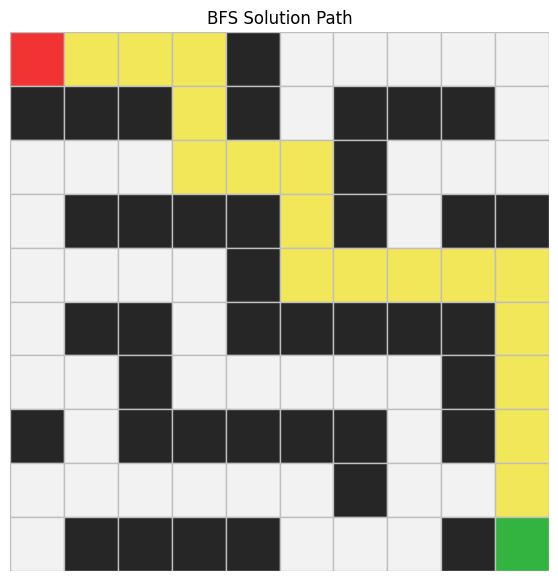

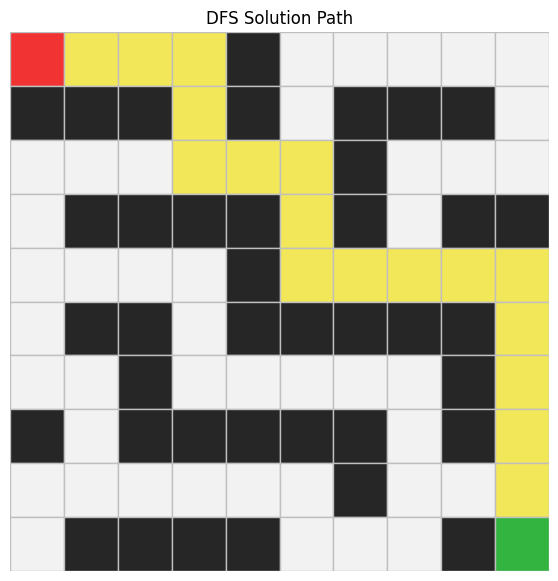

In [92]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

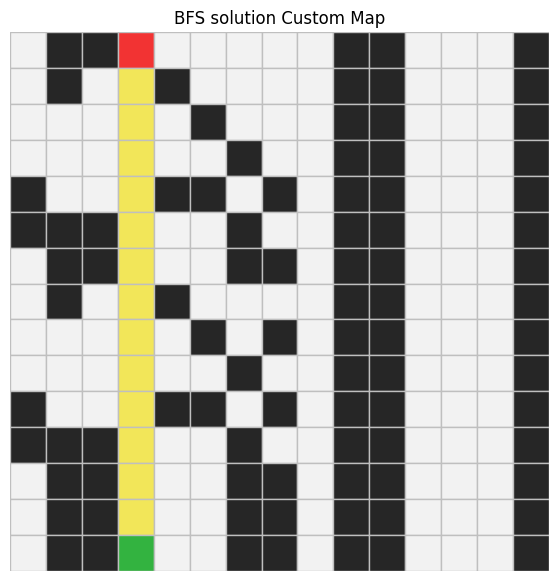

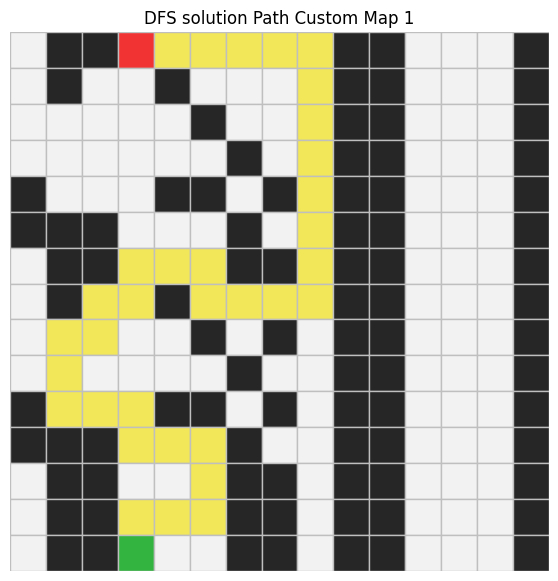

In [93]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,],
    [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,],
    [1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,],
    [0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,],
    [1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,],
    [0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,],

    # Replace this with your own grid.
]

custom_start_1 = (0,3)
custom_goal_1 = (14,3)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

bfs_result_1=custom_results_1[0]
dfs_result_1=custom_results_1[1]
plot_path(custom_grid_1, custom_start_1, custom_goal_1, path=bfs_result_1.path, title='BFS solution Custom Map')
plot_path(custom_grid_1, custom_start_1, custom_goal_1, path=dfs_result_1.path, title='DFS solution Path Custom Map 1')


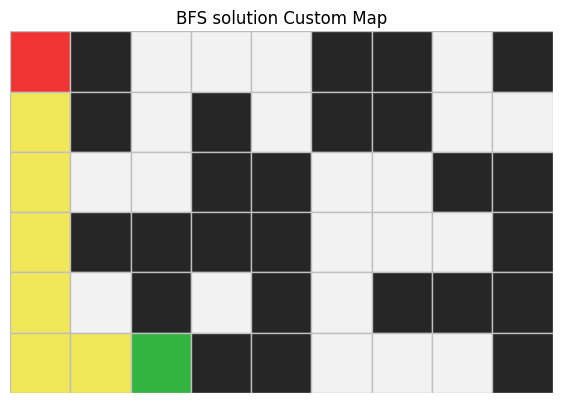

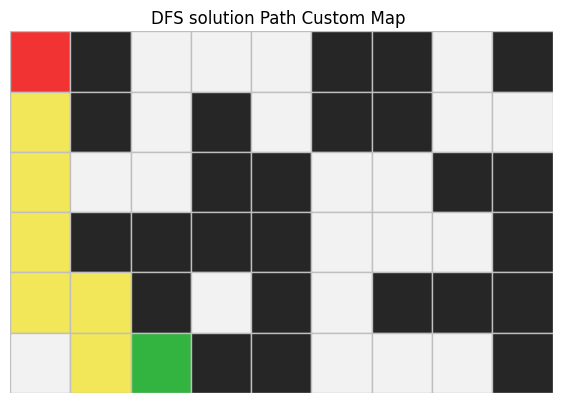

In [94]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 1, 0, 0, 0, 1, 1, 0, 1],
    [0, 1, 0, 1, 0, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 1, 1],
    [0, 1, 1, 1, 1, 0, 0, 0, 1],
    [0, 0, 1, 0, 1, 0, 1, 1, 1],
    [0, 0, 0, 1, 1, 0, 0, 0, 1],
    # Replace this with your own grid.
]

custom_start_2 = (0,0)
custom_goal_2 =(5,2)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

bfs_result_2=custom_results_2[0]
dfs_result_2=custom_results_2[1]
plot_path(custom_grid_2, custom_start_2, custom_goal_2, path=bfs_result_2.path, title='BFS solution Custom Map')
plot_path(custom_grid_2, custom_start_2, custom_goal_2, path=dfs_result_2.path, title='DFS solution Path Custom Map ')



# 15. Reflection Questions



**15.1 Problem Formulation**

What is a state in this lab?
Answer: The state is a cell.

What is an action?
Answer: This is what determines the direction in which the drone should move whether it should move up,down, left or right

What does the result function do?
Answer: IT takes the current state the drone is at and shows where the next state of the drone will be.

Why is it useful to separate the problem definition from the search algorithm?
Answer:
It allows the Best first search algorithm to work on multiple problems.



15.2 BFS

Why does BFS use a FIFO queue?
Answer: it makes sure that the nodes are expanded in the order in which they were added

Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
Answer:
Because the algorithm works using the shortest possible path. it tries to reach the goal by using the shortest distance.


What role does the reached set play in BFS?
Answer:
it takes record of the cell that has
already been explored.

15.3 DFS

Why does DFS use a stack?
Answer: the algorithm uses a stack because the algorithm uses the newest cell that it just found so the stack is what gives back the last thing that was added




Is DFS guaranteed to find the shortest path? Explain.
No. Dfs does not consider the shortest possible path unlike the bfs. Dfs takes one path and goes down down to see if it would reach it goal and if it doesnt, it comes back and tries another path


Under what conditions can DFS use less memory than BFS?
Answer: when the grid is very big dfs uses less


Under what conditions can DFS perform badly?
Answer: when the grid is big and it takes a path and it explores all the way down just to find out that it doesnt work then it now has to come back and start again from the top


15.4 DLS

What happens when the depth limit is too small?
Answer:
if it is too small dfs stops before it gets to its goal


What is the meaning of "cutoff"?
Answer:
it means that the search has stopped becuase the depth limit has been reahced so the goal cannot be attained


How is DLS different from ordinary DFS?
Answer:
dls goes more in depth than dfs


Why do we use path-cycle checking in DLS?
Answer:
It prevents the search from going back to a node that is already in its current path



15.5 IDS
Why does IDS repeat DLS with increasing limits?
Answer:
this is because we do not know the depth of the goal


Why can IDS be complete even though DLS with a small limit is not?
Answer:
This is because ids makes sure to find the goal if the goal exists but for dls once the limit has been reached it just stops and it sometimes misses the goal.



Why does IDS use less memory than BFS?
Answer:
ids only stores the nodes along the current path but bfs does not.



What is the cost of repeatedly searching from the root?
Answer:
for each round, ids starts straight from the roots so some nodes are epxored multiple times



15.6 Real-World Drone Context
In a real drone application, what might make one route safer or more practical than another?
Answer:


Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
Answer:



Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
Answer:


What limitations does this grid model have compared with real drone navigation?


